In [53]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/readme[1].txt
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/MSR-LA - 3467.docx
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/7981.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/6234.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/1269.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/3863.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/6241.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/10304.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/623.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/2193.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/11925.jpg
/kaggle/input/datasets/shaunthesh

In [54]:
# doing this on kaggle as the df is already loaded, so bear wid me

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [56]:
# ok now I already know I'm gonna "STRONGLY DISLIKE" this part specifically for this df, but we have to do the data prep

In [57]:
base_dir = '/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages'
cat_dir = os.path.join(base_dir, 'Cat')
dog_dir = os.path.join(base_dir, 'Dog')

In [58]:
# getting all the image paths

cat_images = [os.path.join(cat_dir, f) for f in os.listdir(cat_dir) if f.endswith('.jpg')]
dog_images = [os.path.join(dog_dir, f) for f in os.listdir(dog_dir) if f.endswith('.jpg')]

print(f"Found {len(cat_images)} cat images and {len(dog_images)} dog images.")

Found 12500 cat images and 12500 dog images.


In [59]:
# good, that went smoothly. Now, we'll perform the split in train n validation 80, 20
# PS: Random state will always b 20 for me, it's my daughter's birth date

In [60]:
train_cats, val_cats = train_test_split(cat_images, test_size = 0.2, random_state = 20)
train_dogs, val_dogs = train_test_split(dog_images, test_size = 0.2, random_state = 20)
print(f"Training set: {len(train_cats)} cats, {len(train_dogs)} dogs")
print(f"Validation set: {len(val_cats)} cats, {len(val_dogs)} dogs")

Training set: 10000 cats, 10000 dogs
Validation set: 2500 cats, 2500 dogs


In [61]:
# well time to create the directory structure for ImageDataGenerator

working_dir = '/kaggle/working/cats_dogs_split'
train_dir = os.path.join(working_dir, 'train')
val_dir = os.path.join(working_dir, 'validation')

for split_dir in [train_dir, val_dir]:
    for class_name in ['cats', 'dogs']:
        os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)

In [62]:
# Copying files into respective folders
def copy_images(image_list, dest_dir, class_name):
    for img_path in image_list:
        filename = os.path.basename(img_path)
        dest_path = os.path.join(dest_dir, class_name, filename)
        try:
            shutil.copy(img_path, dest_path)
        except Exception as e:
            print(f"Skipped corrupted file: {filename} ({e})")

copy_images(train_cats, train_dir, 'cats')
copy_images(train_dogs, train_dir, 'dogs')
copy_images(val_cats, val_dir, 'cats')
copy_images(val_dogs, val_dir, 'dogs')

In [63]:
# setting up data generators with augmentation, while making sure that we keep the horizontal_flip as true coz it's superuseful for animals

In [64]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [65]:
# now for the validation generator, ofc we wont do augmentation, just normalisation
val_datagen = ImageDataGenerator(rescale=1./255)

In [66]:
# loading the data for our gens

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),   # Resize to 150x150
    batch_size=32,
    class_mode='categorical'  # For categorical cross-entropy
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

print(f"Training batches: {train_generator.samples // train_generator.batch_size}")
print(f"Validation batches: {validation_generator.samples // validation_generator.batch_size}")

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Training batches: 625
Validation batches: 156


In [67]:
# Finallyyyy... our CNN model building

In [68]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 4
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dropout(0.5),     # Prevent overfitting
    layers.Dense(512, activation='relu'),
    layers.Dense(2, activation='softmax')  # 2 classes: cat/dog

    ])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,634 (13.17 MB)

 Trainable params: 3,453,634 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# now compiling and training with SGD


model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training...
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    verbose=1
)

Epoch 1/15
156/625 ━━━━━━━━━━━━━━━━━━━━ 1:30 193ms/step - accuracy: 0.4969 - loss: 0.6947

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) UNKNOWN:  UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7c80614ae840>
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.12/dist-p


# **GREAT A FEW CORRPUTED IMAGES BROKE DOWN MY GODDAMN MODEL!!!!!!!** 

# **GONNA HAVE TO RESTART EVERYTHING BUT REMOVE THE CORRPUT FILES FIRST :)**


In [70]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image

In [71]:
# Data cleaning n preprocessing

In [72]:
# scanning and removing corrput files and hoping to god that this works
base_dir = '/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages'
cat_dir = os.path.join(base_dir, 'Cat')
dog_dir = os.path.join(base_dir, 'Dog')

def remove_corrupted_images(folder_path, class_name):
    removed_count = 0
    valid_images = []
    
    for filename in os.listdir(folder_path):
        filepath = os.path.join(folder_path, filename)
        
        # Skipping non-jpg files (like .db)
        if not filename.endswith('.jpg'):
            continue
            
        try:
            # Trying to open the image with PIL and Verifying it's a valid image
            img = Image.open(filepath)
            img.verify()
            
            # If we get here, it's valid. Re-open to check mode (some break after verify)
            img = Image.open(filepath)
            if img.mode != "L":
                pass 
            valid_images.append(filepath)
            
        except Exception:
            # If it fails, delete it!
            print(f"Deleting corrupted file: {filename}")
            try:
                os.remove(filepath)
                removed_count += 1
            except OSError:
                pass
                
    print(f"Cleaned {class_name}: Removed {removed_count} bad files. Kept {len(valid_images)}.")
    return valid_images

In [73]:
# Cleaning both folders
valid_cats = remove_corrupted_images(cat_dir, 'Cats')
valid_dogs = remove_corrupted_images(dog_dir, 'Dogs')

print(f"Total valid images: {len(valid_cats)} cats, {len(valid_dogs)} dogs")

Deleting corrupted file: 666.jpg
Cleaned Cats: Removed 0 bad files. Kept 12499.
Deleting corrupted file: 11702.jpg
Cleaned Dogs: Removed 0 bad files. Kept 12499.
Total valid images: 12499 cats, 12499 dogs


In [74]:
# Splitting into training n validation


train_cats, val_cats = train_test_split(valid_cats, test_size=0.2, random_state=20)
train_dogs, val_dogs = train_test_split(valid_dogs, test_size=0.2, random_state=20)

print(f"Training set: {len(train_cats)} cats, {len(train_dogs)} dogs")
print(f"Validation set: {len(val_cats)} cats, {len(val_dogs)} dogs")

Training set: 9999 cats, 9999 dogs
Validation set: 2500 cats, 2500 dogs


In [75]:
# Creating directory structure for ImageDataGenerator
working_dir = '/kaggle/working/cats_dogs_clean'
train_dir = os.path.join(working_dir, 'train')
val_dir = os.path.join(working_dir, 'validation')

# Cleaning up previous runs if any
if os.path.exists(working_dir):
    shutil.rmtree(working_dir)

for split_dir in [train_dir, val_dir]:
    for class_name in ['cats', 'dogs']:
        os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)

In [76]:
# Copying files
def copy_images(image_list, dest_dir, class_name):
    for img_path in image_list:
        filename = os.path.basename(img_path)
        dest_path = os.path.join(dest_dir, class_name, filename)
        shutil.copy(img_path, dest_path)

# This is gonna take an eternity...
copy_images(train_cats, train_dir, 'cats')
copy_images(train_dogs, train_dir, 'dogs')
copy_images(val_cats, val_dir, 'cats')
copy_images(val_dogs, val_dir, 'dogs')
print("Files copied successfully!")

Files copied successfully!


In [77]:
# again data augmentation and preprocessin

In [78]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation generator - NO augmentation only normalising
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 19998 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [79]:
# building our cnn model

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,042 (13.18 MB)

 Trainable params: 3,454,338 (13.18 MB)

 Non-trainable params: 704 (2.75 KB)

In [80]:
# now the compiling n training (where things went to hell last time)

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 130s 201ms/step - accuracy: 0.5854 - loss: 1.0272 - val_accuracy: 0.6893 - val_loss: 0.5951 - learning_rate: 1.0000e-04
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7188 - loss: 0.6717 - val_accuracy: 0.6905 - val_loss: 0.5914 - learning_rate: 1.0000e-04
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 121s 194ms/step - accuracy: 0.6545 - loss: 0.7420 - val_accuracy: 0.7330 - val_loss: 0.5383 - learning_rate: 1.0000e-04
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5625 - loss: 0.9818 - val_accuracy: 0.7338 - val_loss: 0.5382 - learning_rate: 1.0000e-04
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 123s 197ms/step - accuracy: 0.6833 - loss: 0.6341 - val_accuracy: 0.7544 - val_loss: 0.4969 - learning_rate: 1.0000e-04
Epoch 6/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6250 - loss: 0.5381 - val_accuracy: 0.7586 - val_loss: 0.4959 - learning_rate: 1.0000e-04
Epoch 7/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 121s 194m

In [81]:
# That took a longgg longgggggggg longgggggggggggestttttt time


# **You should really update the assignemnts coz noway here SGD would have been effectiver than Adam!!!**
# It would have magically adapted LR per parameter**


In [84]:
# Evauating n [predicting]

Validation Accuracy: 0.7906 (79.06%)


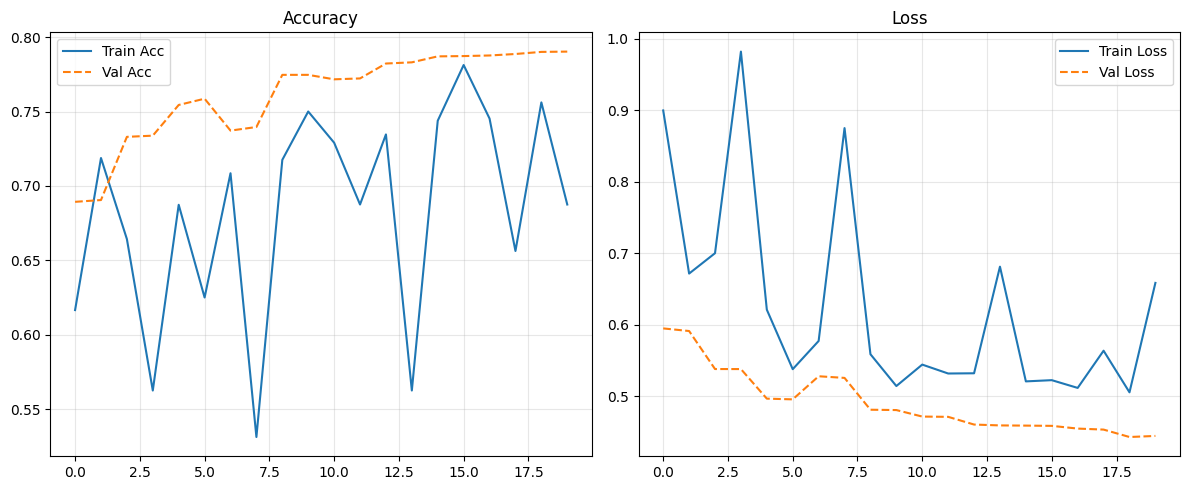

In [85]:
val_loss, val_acc = model.evaluate(validation_generator, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc', linestyle='--')
plt.title('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [86]:
# Quick Prediction Test
def predict_single_image(model, img_path):
    img = load_img(img_path, target_size=(150, 150))
    img_array = img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)
    
    pred = model.predict(img_array, verbose=0)[0]
    label = "Dog" if np.argmax(pred) == 0 else "Cat"
    conf = np.max(pred)
    return label, conf

# Test on one random validation image
test_img_path = val_cats[0]
label, conf = predict_single_image(model, test_img_path)
print(f"\nTest Prediction: {os.path.basename(test_img_path)} -> {label} ({conf:.1%})")

print("Success! No more crashes. Model trained and evaluated.")


Test Prediction: 86.jpg -> Dog (98.5%)
Success! No more crashes. Model trained and evaluated.
